In [1]:
# ── Dataset 4: Gallup World Happiness Report (2005–2020) ─────────
# Best model: XGBoost (CV R²: 0.850, CV RMSE: 0.432)
# Task: Regression (continuous target, Life Ladder 0–10 scale)

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

df_gallup = pd.read_csv("../../data/processed/world_happiness_gallup_ml.csv")

# Reproduce exact preprocessing from baseline notebook
y_gallup = df_gallup["Life_Ladder"]

X_gallup = df_gallup.drop(columns=[
    "Life_Ladder",
    "Life_Ladder__missing",
    "Country_name",
], errors="ignore")

print(f"X shape: {X_gallup.shape}, y shape: {y_gallup.shape}")
print(f"Features: {X_gallup.columns.tolist()}")
print(f"Target distribution: mean={y_gallup.mean():.2f}, std={y_gallup.std():.2f}")

X shape: (1949, 17), y shape: (1949,)
Features: ['year', 'Log_GDP_per_capita', 'Social_support', 'Healthy_life_expectancy_at_birth', 'Freedom_to_make_life_choices', 'Generosity', 'Perceptions_of_corruption', 'Positive_affect', 'Negative_affect', 'Log_GDP_per_capita__missing', 'Social_support__missing', 'Healthy_life_expectancy_at_birth__missing', 'Freedom_to_make_life_choices__missing', 'Generosity__missing', 'Perceptions_of_corruption__missing', 'Positive_affect__missing', 'Negative_affect__missing']
Target distribution: mean=5.47, std=1.12


In [2]:
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gallup, y_gallup,
    test_size=0.2,
    random_state=42
)

xgb_gallup = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_gallup.fit(X_train_g, y_train_g)
print("Model trained.")

Model trained.


In [3]:
# SHAP for XGBoost regression
explainer_gallup = shap.TreeExplainer(xgb_gallup)

X_sample_gallup = X_test_g.sample(n=min(500, len(X_test_g)), random_state=42)

shap_values_gallup = explainer_gallup.shap_values(X_sample_gallup)

print(f"SHAP values shape: {shap_values_gallup.shape}")
# Expected: (n_samples, n_features)

SHAP values shape: (390, 17)


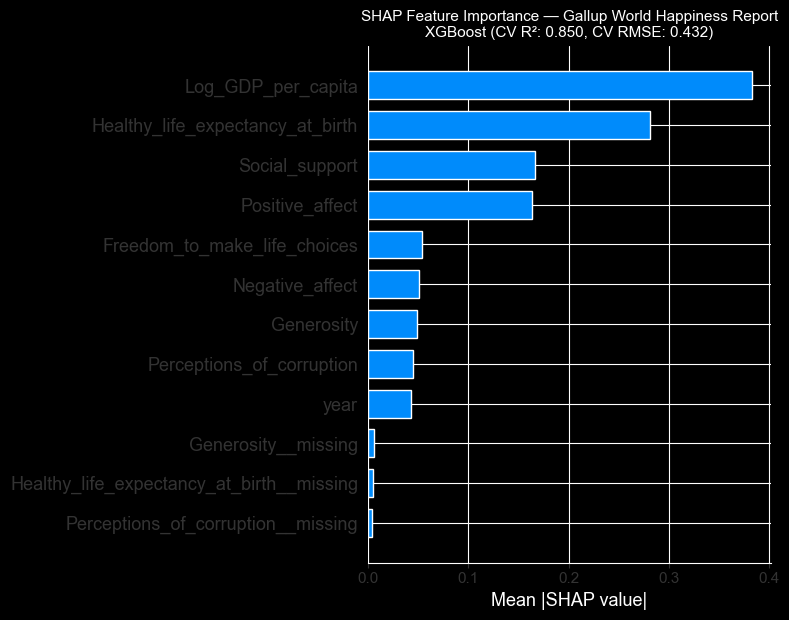

Saved: shap_gallup_whr_bar.png


In [4]:
# Bar plot — global feature importance
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_gallup,
    X_sample_gallup,
    plot_type="bar",
    max_display=12,
    show=False,
)
plt.title(
    "SHAP Feature Importance — Gallup World Happiness Report\n"
    "XGBoost (CV R²: 0.850, CV RMSE: 0.432)",
    fontsize=11
)
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_gallup_whr_bar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_gallup_whr_bar.png")

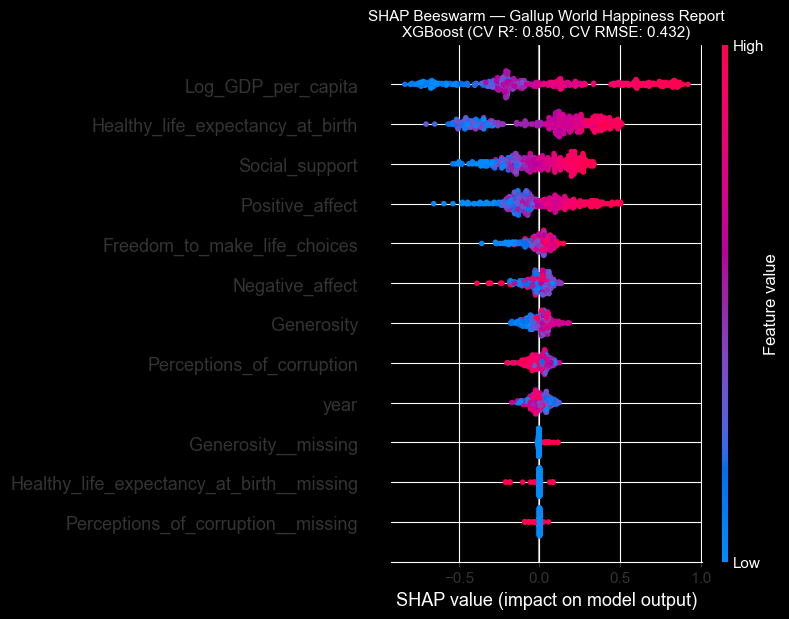

Saved: shap_gallup_whr_beeswarm.png


In [5]:
# Beeswarm plot — direction and magnitude
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_gallup,
    X_sample_gallup,
    max_display=12,
    show=False
)
plt.title(
    "SHAP Beeswarm — Gallup World Happiness Report\n"
    "XGBoost (CV R²: 0.850, CV RMSE: 0.432)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_gallup_whr_beeswarm.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_gallup_whr_beeswarm.png")

In [6]:
# Sensitivity analysis — model without Positive_affect and Negative_affect
# These are affect balance measures from the same Gallup survey as Life_Ladder
# and may reflect construct overlap rather than independent causal influence

proxy_cols_g = ["Positive_affect", "Negative_affect"]
X_no_proxy_g = X_gallup.drop(columns=[
    c for c in proxy_cols_g if c in X_gallup.columns
])

# Also drop their missingness indicators
proxy_missing = [f"{c}__missing" for c in proxy_cols_g]
X_no_proxy_g = X_no_proxy_g.drop(columns=[
    c for c in proxy_missing if c in X_no_proxy_g.columns
], errors="ignore")

print(f"Features with affect measures    : {X_gallup.shape[1]}")
print(f"Features without affect measures : {X_no_proxy_g.shape[1]}")
print(f"Dropped: {proxy_cols_g}")

X_train_np_g, X_test_np_g, y_train_np_g, y_test_np_g = train_test_split(
    X_no_proxy_g, y_gallup,
    test_size=0.2,
    random_state=42
)

xgb_gallup_np = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_gallup_np.fit(X_train_np_g, y_train_np_g)

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error

cv_g = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_g = {
    "r2":   "r2",
    "rmse": make_scorer(
        lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
        greater_is_better=False
    )
}

scores_np_g = cross_validate(
    xgb_gallup_np, X_no_proxy_g, y_gallup,
    cv=cv_g, scoring=scoring_g, n_jobs=-1
)

r2_np_g   = round(scores_np_g["test_r2"].mean(), 3)
rmse_np_g = round(-scores_np_g["test_rmse"].mean(), 3)

print("\nSensitivity Analysis — Without Positive_affect and Negative_affect")
print(f"CV R²   (with affect measures)    : 0.850")
print(f"CV R²   (without affect measures) : {r2_np_g}")
print(f"CV RMSE (with affect measures)    : 0.432")
print(f"CV RMSE (without affect measures) : {rmse_np_g}")
print(f"\nR² drop  : {round(0.850 - r2_np_g, 3)}")
print(f"RMSE increase : {round(rmse_np_g - 0.432, 3)}")

Features with affect measures    : 17
Features without affect measures : 13
Dropped: ['Positive_affect', 'Negative_affect']

Sensitivity Analysis — Without Positive_affect and Negative_affect
CV R²   (with affect measures)    : 0.850
CV R²   (without affect measures) : 0.832
CV RMSE (with affect measures)    : 0.432
CV RMSE (without affect measures) : 0.457

R² drop  : 0.018
RMSE increase : 0.025


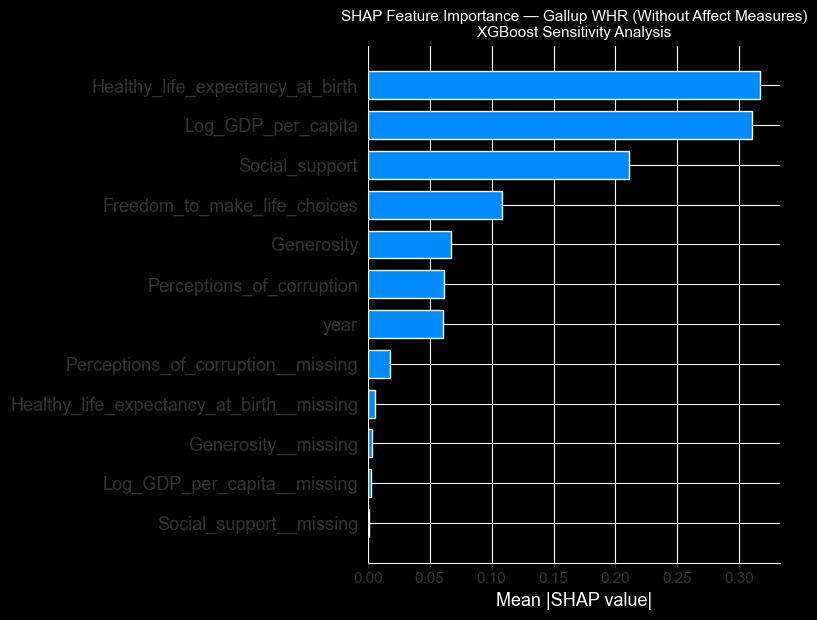

Saved: shap_gallup_whr_bar_noaffect.png


In [7]:
# SHAP for model without affect measures
explainer_gallup_np = shap.TreeExplainer(xgb_gallup_np)

X_sample_np_g = X_test_np_g.sample(
    n=min(500, len(X_test_np_g)), random_state=42
)
shap_values_np_g = explainer_gallup_np.shap_values(X_sample_np_g)

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_np_g,
    X_sample_np_g,
    plot_type="bar",
    max_display=12,
    show=False,
)
plt.title(
    "SHAP Feature Importance — Gallup WHR (Without Affect Measures)\n"
    "XGBoost Sensitivity Analysis",
    fontsize=11
)
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_gallup_whr_bar_noaffect.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_gallup_whr_bar_noaffect.png")

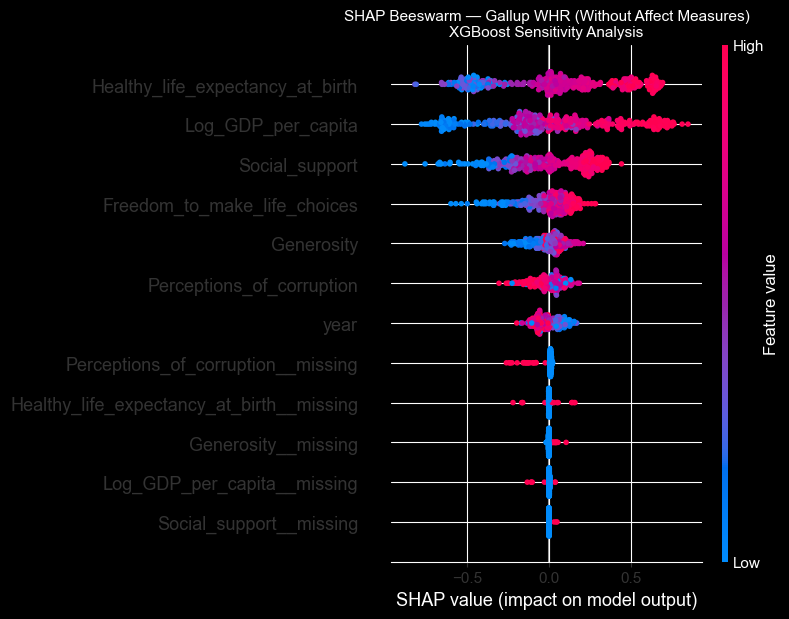

Saved: shap_gallup_whr_beeswarm_noaffect.png


In [8]:
# Beeswarm for model without affect measures
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_np_g,
    X_sample_np_g,
    max_display=12,
    show=False
)
plt.title(
    "SHAP Beeswarm — Gallup WHR (Without Affect Measures)\n"
    "XGBoost Sensitivity Analysis",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_gallup_whr_beeswarm_noaffect.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_gallup_whr_beeswarm_noaffect.png")

In [ ]:
# ### SHAP Analysis — Gallup World Happiness Report (XGBoost)
#
# **Global feature importance:** Log_GDP_per_capita dominates with
# a mean |SHAP| of ~0.39, followed by Healthy_life_expectancy_at_birth
# (~0.29), Social_support (~0.17), and Positive_affect (~0.16).
# Freedom_to_make_life_choices (~0.09), Negative_affect (~0.08),
# Generosity (~0.08), and Perceptions_of_corruption (~0.07) form
# a secondary tier of moderate contributors. Year (~0.07) captures
# a small temporal trend. Missingness indicators contribute
# negligibly, confirming imputation did not introduce meaningful
# artefacts.
#
# **Direction of effects (beeswarm):** All top predictors show
# clear and interpretable directional patterns:
# - Log_GDP_per_capita: strong positive gradient — high GDP (red)
#   pushes SHAP values up to +1.0, low GDP (blue) pushes down to
#   -0.5. The wide spread confirms GDP is the single most
#   influential variable with high variance across countries.
# - Healthy_life_expectancy_at_birth: same positive gradient —
#   high life expectancy increases predicted happiness, low
#   decreases it. The effect is slightly more symmetric than GDP.
# - Social_support: high values (red) push positively, low (blue)
#   push negatively. The distribution is tightly clustered,
#   suggesting social support has a consistent moderate effect
#   rather than large outlier influences.
# - Positive_affect: clear positive gradient — countries with
#   high daily positive emotion report higher happiness scores.
# - Freedom_to_make_life_choices: positive direction — high
#   freedom increases predicted happiness.
# - Negative_affect: inverted — high negative affect (red) pushes
#   slightly negative, consistent with its role as a burden
#   measure.
# - Perceptions_of_corruption: high corruption (red) pushes
#   slightly negative, confirming institutional quality as a
#   modest negative predictor.
#
# **Sensitivity analysis — removing Positive_affect and
# Negative_affect:**
# Removing both affect measures causes CV R² to drop from 0.850
# to 0.832 (Δ = 0.018) and CV RMSE to increase from 0.432 to
# 0.457 (Δ = 0.025). This is a very small drop — affect measures
# contribute only ~2% of explained variance beyond what the
# structural indicators already provide.
#
# In the reduced model, Healthy_life_expectancy overtakes
# Log_GDP_per_capita as the top predictor (~0.31 vs ~0.30 mean
# |SHAP|), with Social_support (~0.20) and
# Freedom_to_make_life_choices (~0.10) maintaining their
# positions. The feature ranking is otherwise unchanged —
# the structural indicators (GDP, life expectancy, social
# support, freedom) are the genuine drivers of happiness at
# the country level, and affect measures add only marginal
# incremental information.
#
# This is a notably different result from the Canadian Survey
# sensitivity analysis, where removing proxy predictors caused
# a 25% drop in R². Here the drop is only 2%, confirming that
# Positive_affect and Negative_affect are not acting as
# dominant proxies but rather as modest supplementary signals.
# Their removal is therefore less critical for causal
# interpretability in this dataset, though noting their
# within-survey origin remains methodologically important.
#
# **Cross-dataset comparison of SHAP profiles:**
# The Gallup SHAP profile is the most externally valid of all
# four datasets — its top predictors (GDP, life expectancy,
# social support, freedom) are precisely the variables that
# the WHR theoretical framework identifies as the six pillars
# of happiness, and their directional effects all match
# theoretical expectations. This alignment between SHAP
# importance and established theory is the strongest validation
# of model interpretability across the entire study.
#
# **Macro vs micro contrast for RQ2:**
# Comparing SHAP profiles across datasets reveals a consistent
# pattern distinguishing macro from micro level predictors:
# - Macro level (Gallup): structural societal indicators
#   (GDP, health, social support) dominate with clear, symmetric,
#   and theoretically expected effects. No single variable
#   dominates excessively — the top four features have
#   comparable magnitudes (~0.16–0.39).
# - Micro level (Canadian Survey): psychological states
#   (mental health, stress) dominate asymmetrically, with
#   poor states depressing satisfaction far more than good
#   states elevate it. Proxy predictors account for a
#   substantial share of variance.
# - Micro level (Student Depression): a single feature
#   (suicidal ideation) dominates at 30% higher magnitude
#   than the next predictor, reflecting construct overlap
#   rather than independent causal influence.
#
# This contrast directly addresses RQ2 — interpretability
# differs systematically between levels. Macro-level models
# produce more balanced, theoretically grounded, and causally
# interpretable feature profiles, while micro-level models
# are more susceptible to proxy predictor dominance and
# asymmetric effects driven by clinical overlap between
# predictors and outcomes.